### Setup base model and data

In [ ]:

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os
from sklearn.linear_model import LogisticRegression

os.makedirs("plots", exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# blobs on a circle
num_classes = 15
R_circle    = 4.0
sigma_blob  = 0.6

angles  = 2 * np.pi * np.arange(num_classes) / num_classes
centres = np.stack([R_circle * np.cos(angles), R_circle * np.sin(angles)], axis=1)

def gen(n, seed):
    r = np.random.default_rng(seed)
    y = r.integers(0, num_classes, n)
    X = centres[y] + r.normal(0, sigma_blob, size=(n, 2))
    return X.astype(np.float32), y.astype(np.int64)

X_train, y_train = gen(2000, seed=0)
X_calib, y_calib = gen(100,  seed=1)     
X_test,  y_test  = gen(2000, seed=2)
n_calib = 100

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# score: S(x, y) = 1 - p_hat(y | x)   (non-negative, negatively oriented)
def scores_all(Xa):
    """(m, K) matrix of S(x, y) for every candidate label y."""
    return 1.0 - model.predict_proba(Xa)

S_calib_all = scores_all(X_calib)                    # (n_calib, K)
S_calib = S_calib_all[np.arange(n_calib), y_calib]   # true-label calibration scores
S_test_all = scores_all(X_test)
S_test  = S_test_all[np.arange(len(X_test)), y_test]
acc = model.score(X_train, y_train)

print("base model accuracy (calib):", (model.predict(X_calib) == y_calib).mean())

base model accuracy (calib): 0.91


In [30]:
def score_matrix(Xa):
    return -np.log(model.predict_proba(Xa) + 1e-12)

### Training a model of coverage levels

In [82]:
from ablation_utils.neural_net import make_features, make_loader, multi_lambda_run_train_alpha_net

n_loo = n_calib - 1
Sigma_loo = S_calib.sum() - S_calib
E_loo = (n_loo + 1) * S_calib_all / (Sigma_loo[:, None] + S_calib_all)
u_loo = np.ones(n_calib, dtype=np.float32)          # no EU weighting here -> flat lambda

feats_loo = make_features(Sigma_loo, S_calib_all, u_loo)   # (n_calib, K+2): [Sigma, sorted scores, u]
X_train_alpha = torch.tensor(feats_loo, dtype=torch.float32)
E_train_alpha = torch.tensor(E_loo, dtype=torch.float32)

train_loader = make_loader(Sigma_loo, S_calib_all, E_loo, u_loo, batch_size=32, shuffle=True)

lambdas = [10, 20, 30]
num_runs = 4
all_results = multi_lambda_run_train_alpha_net(
train_loader, lambdas, num_epochs=200, lr=1e-3, device=device, num_runs=num_runs)


[lambda=10] run 1/4
  lam 10 | run 1 | epoch 0/200 | loss 10.5689 | size 0.6419 | alpha 0.9927
  lam 10 | run 1 | epoch 25/200 | loss 6.1638 | size 1.7201 | alpha 0.4444
  lam 10 | run 1 | epoch 50/200 | loss 6.1118 | size 1.6356 | alpha 0.4476
  lam 10 | run 1 | epoch 75/200 | loss 6.1380 | size 1.6761 | alpha 0.4462
  lam 10 | run 1 | epoch 100/200 | loss 6.1407 | size 1.6527 | alpha 0.4488
  lam 10 | run 1 | epoch 125/200 | loss 6.1367 | size 1.6393 | alpha 0.4497
  lam 10 | run 1 | epoch 150/200 | loss 6.1788 | size 1.6678 | alpha 0.4511
  lam 10 | run 1 | epoch 175/200 | loss 6.1501 | size 1.6341 | alpha 0.4516
  lam 10 | run 1 | epoch 199/200 | loss 6.1277 | size 1.6118 | alpha 0.4516

[lambda=10] run 2/4
  lam 10 | run 2 | epoch 0/200 | loss 10.5209 | size 0.5987 | alpha 0.9922
  lam 10 | run 2 | epoch 25/200 | loss 6.2098 | size 1.6251 | alpha 0.4585
  lam 10 | run 2 | epoch 50/200 | loss 6.1475 | size 1.6303 | alpha 0.4517
  lam 10 | run 2 | epoch 75/200 | loss 6.1213 | size 

c:\Users\User\Documents\learning-uncertainty-aware-policies\classification\neural_net.py:424: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


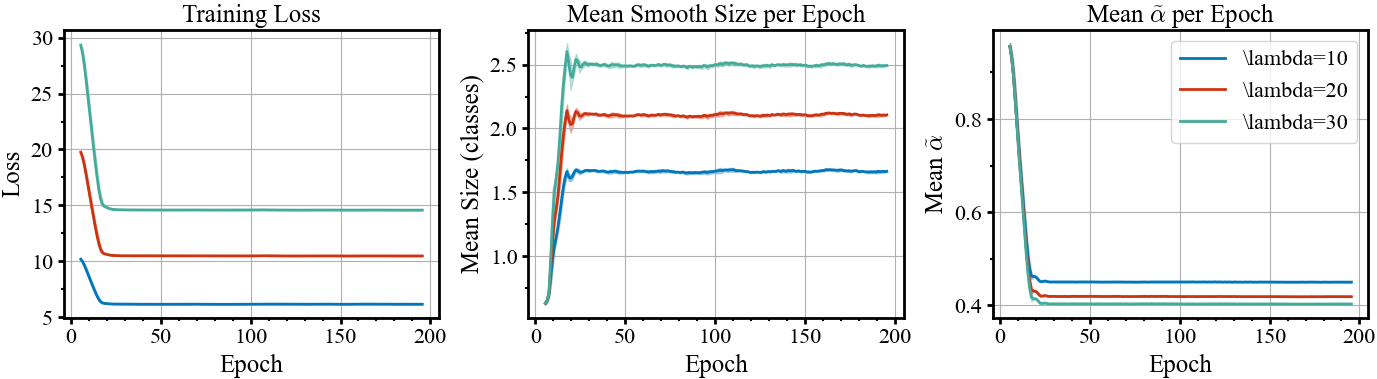

In [83]:
import os
import matplotlib.pyplot as plt
from ablation_utils.neural_net import plot_performance

os.makedirs("plots", exist_ok=True)
colors = {lambdas[0]: "#0077bb", lambdas[1]: "#cc3311", lambdas[2]: "#44aa99"}

plot_performance(all_results, "plots/training_classification.pdf",
                  labels=colors, keyword=r"\lambda", window_size=10)

### Learned coverage policy evaluation

C:\Users\User\AppData\Local\Temp\ipykernel_23232\3103149364.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


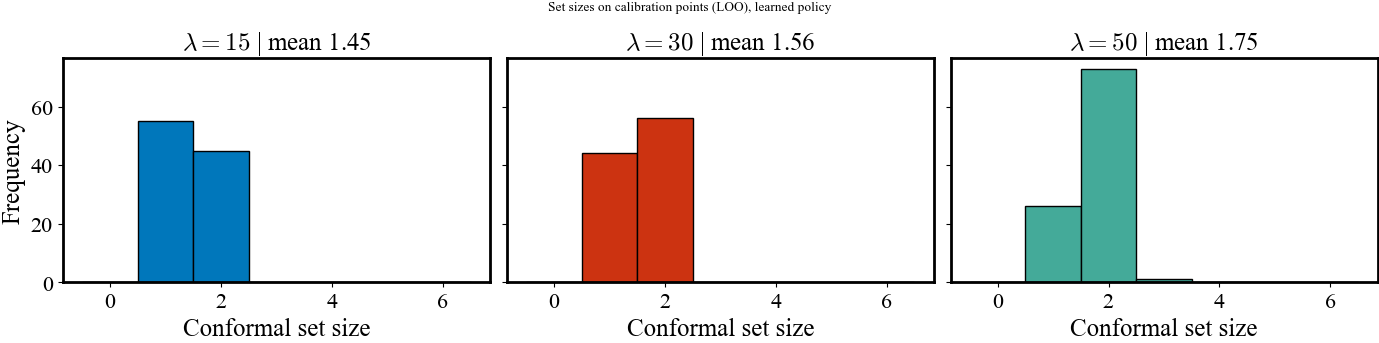

lambda=15: mean set size (calibration, LOO): 1.450
lambda=30: mean set size (calibration, LOO): 1.560
lambda=50: mean set size (calibration, LOO): 1.750


In [ ]:
#  conformal set evaluation

def exact_size(Sigma, s_cand, n, alpha):
    """Exact set size at level alpha"""
    if alpha <= 1.0 / (n + 1):
        return len(s_cand)                      # all labels in set
    tau = Sigma / ((n + 1) * alpha - 1.0)
    return int(np.sum(s_cand <= tau))

def covered(Sigma, s_true, n, alpha):
    """true label inside the set at level alpha"""
    E_true = (n + 1) * s_true / (Sigma + s_true)
    return E_true <= 1.0 / alpha

# evaluate the learned policy on the calibration points (LOO), one net per lambda

sizes_calib = {}
for lam in lambdas:
    net = all_results[lam]['nets'][0]
    net.eval()
    with torch.no_grad():
        a_loo = net(X_train_alpha.to(device)).cpu().numpy()
    sizes_calib[lam] = np.array([exact_size(Sigma_loo[i], S_calib_all[i], n_loo, a_loo[i])
                                 for i in range(n_calib)])

fig, axs = plt.subplots(1, len(lambdas), figsize=(14, 3.6), sharey=True)
for ax, lam in zip(axs, lambdas):
    ax.hist(sizes_calib[lam], bins=np.arange(num_classes//2 + 1) - 0.5, edgecolor='k', color=colors[lam])
    ax.set_xlabel("Conformal set size")
    ax.set_title(rf"$\lambda={lam}$ | mean {sizes_calib[lam].mean():.2f}")
axs[0].set_ylabel("Frequency")
plt.suptitle("Set sizes on calibration points (LOO), learned policy")
plt.tight_layout()
plt.show()

for lam in lambdas:
    print(f"lambda={lam}: mean set size (calibration, LOO): {sizes_calib[lam].mean():.3f}")


### Exact optimal coverage policy

A candidate $y$ enters the set when its soft-rank e-value is below the threshold:

$$\frac{(n+1)\,S(x,y)}{\Sigma + S(x,y)} \le \frac{1}{\tilde\alpha}
\iff S(x,y) \le \tau(\tilde\alpha) := \frac{\Sigma}{(n+1)\tilde\alpha - 1},
\qquad \Sigma := \sum_{i=1}^{n} S(X_i, Y_i),\qquad \tilde\alpha > \tfrac{1}{n+1}$$

With sorted candidate scores $s_{(1)} \le \dots \le s_{(K)}$ at a test point,
the optimum can be found by iterating through the breakpoints

$$\beta_j = \frac{1}{n+1}\left(\frac{\Sigma}{s_{(j)}} + 1\right),\qquad \beta_1 \ge \beta_2 \ge \dots \ge \beta_K .$$




In [88]:
# exact minimiser of L(alpha) = Size(alpha) + lambda * alpha 

def exact_min(Sigma, s_cand, n, lam, eps=1e-6):
    """Exact minimiser over (1/(n+1), 1]. Returns (alpha*, L*)."""
    s_sorted = np.sort(s_cand)
    breakpoints = ((Sigma / s_sorted )+ 1.0) / (n + 1)          
    cands = np.concatenate([breakpoints + eps, [1.0 / (n + 1) + eps, 1.0]])
    cands = np.unique(cands[(cands > 1.0 / (n + 1)) & (cands <= 1.0)])
    losses = np.array([exact_size(Sigma, s_cand, n, a) + lam * a for a in cands])
    j = int(np.argmin(losses))
    return float(cands[j]), float(losses[j])

def evaluate_policy(Sigma_arr, S_all, S_true, n, alphas):
    """alphas: (m,) per-point levels. Sigma_arr: (m,) array or scalar (broadcast).
    Returns mean alpha, mean exact size, empirical miscoverage."""
    m = len(alphas)
    Sigma_arr = np.broadcast_to(Sigma_arr, (m,))
    sizes = np.array([exact_size(Sigma_arr[i], S_all[i], n, alphas[i]) for i in range(m)])
    miss  = np.array([not covered(Sigma_arr[i], S_true[i], n, alphas[i]) for i in range(m)])
    return float(np.mean(alphas)), float(sizes.mean()), float(miss.mean())

def evaluate_policy_loo(alphas, Sigma=Sigma_loo, S_all=S_calib_all, S_true=S_calib, n=n_loo):
    """LOO episodes: episode i calibrates on the other n_loo points and is tested on point i."""
    return evaluate_policy(Sigma, S_all, S_true, n, np.asarray(alphas, dtype=float))

def learned_alphas(net, feats=X_train_alpha):
    net.eval()
    with torch.no_grad():
        return net(feats.to(device)).cpu().numpy().reshape(-1)

comparison = {}

print(f"Calibration set: n_calib = {n_calib}   (LOO episodes use n = {n_loo})")
print(f"Sigma over LOO episodes: mean {Sigma_loo.mean():.3f}, "
      f"range [{Sigma_loo.min():.3f}, {Sigma_loo.max():.3f}]\n")

header = f"{'lambda':>7} {'policy':>12} {'mean alpha':>12} {'mean size':>11} {'emp. miscov':>12} {'loss':>9}"
print(header)
print("-" * len(header))

for lam in lambdas:
    # ---- exact (elbow enumeration) ----
    a_ex = np.array([exact_min(Sigma_loo[i], S_calib_all[i], n_loo, lam)[0]
                     for i in range(n_calib)])
    mean_a_ex, mean_s_ex, miscoverage_ex = evaluate_policy_loo(a_ex)
    loss_ex = mean_s_ex + lam * mean_a_ex

    # ---- learned, averaged over runs ----
    a_nn_runs = np.stack([learned_alphas(net) for net in all_results[lam]['nets']])
    stats_nn = np.array([evaluate_policy_loo(a) for a in a_nn_runs])  
    mean_a_nn, mean_s_nn, miscoverage_nn = stats_nn.mean(axis=0)
    sd = stats_nn.std(axis=0)
    loss_nn = mean_s_nn + lam * mean_a_nn

    print(f"{lam:>7} {'exact':>12} {mean_a_ex:>12.4f} {mean_s_ex:>11.4f} {miscoverage_ex:>12.3f} {loss_ex:>9.4f}")
    print(f"{'':>7} {'learned':>12} {mean_a_nn:>12.4f} {mean_s_nn:>11.4f} {miscoverage_nn:>12.3f} {loss_nn:>9.4f}")
    print(f"{'':>7} {'(+/- sd)':>12} {sd[0]:>12.4f} {sd[1]:>11.4f} {sd[2]:>12.3f}  "
          f"{'gap: ' + format(loss_nn - loss_ex, '+.4f'):>9}")
    print()

    comparison[lam] = dict(a_ex=a_ex, mean_a_ex=mean_a_ex, mean_s_ex=mean_s_ex, miscoverage_ex=miscoverage_ex, loss_ex=loss_ex,
                           a_nn_runs=a_nn_runs, mean_a_nn=mean_a_nn, mean_s_nn=mean_s_nn, miscoverage_nn=miscoverage_nn, loss_nn=loss_nn)



Calibration set: n_calib = 100   (LOO episodes use n = 99)
Sigma over LOO episodes: mean 32.014, range [31.420, 32.207]

 lambda       policy   mean alpha   mean size  emp. miscov      loss
--------------------------------------------------------------------
     10        exact       0.3712      1.4000        0.030    5.1124
             learned       0.4490      1.3900        0.030    5.8804
            (+/- sd)       0.0020      0.0071        0.000  gap: +0.7680

     20        exact       0.3559      1.6200        0.010    8.7375
             learned       0.4186      1.4950        0.030    9.8670
            (+/- sd)       0.0009      0.0050        0.000  gap: +1.1295

     30        exact       0.3532      1.6800        0.010   12.2772
             learned       0.4033      1.5775        0.030   13.6770
            (+/- sd)       0.0012      0.0109        0.000  gap: +1.3998



In [86]:
Sigma_full = S_calib.sum()
u_test = np.ones(len(X_test), dtype=np.float32)   # matches u_loo: no EU weighting in this notebook

feats_test = torch.tensor(
    make_features(np.full(len(X_test), Sigma_full), S_test_all, u_test),
    dtype=torch.float32)

print(f"Test set: {len(X_test)} points | Sigma (full calibration, n={n_calib}) = {Sigma_full:.3f}")

Test set: 2000 points | Sigma (full calibration, n=100) = 32.338


In [89]:
# repeat evaluation on full dataset
n_test = len(X_test)

print(f"Test set: {n_test} points | Sigma (full calibration, n={n_calib}) = {Sigma_full:.3f}\n")

header = f"{'lambda':>7} {'policy':>12} {'mean alpha':>12} {'mean size':>11} {'emp. miscov':>12} {'loss':>9}"
print(header)
print("-" * len(header))

test_results = {}
for lam in lambdas:
    # ---- exact (elbow enumeration), one per test point ----
    a_ex = np.array([exact_min(Sigma_full, S_test_all[i], n_calib, lam)[0]
                     for i in range(n_test)])
    mean_a_ex, mean_s_ex, miscoverage_ex = evaluate_policy(Sigma_full, S_test_all, S_test, n_calib, a_ex)
    loss_ex = mean_s_ex + lam * mean_a_ex

    # ---- learned, averaged over runs ----
    a_nn_runs = np.stack([learned_alphas(net, feats=feats_test) for net in all_results[lam]['nets']])
    stats_nn = np.array([evaluate_policy(Sigma_full, S_test_all, S_test, n_calib, a) for a in a_nn_runs])
    mean_a_nn, mean_s_nn, miscoverage_nn = stats_nn.mean(axis=0)
    sd = stats_nn.std(axis=0)
    loss_nn = mean_s_nn + lam * mean_a_nn

    print(f"{lam:>7} {'exact':>12} {mean_a_ex:>12.4f} {mean_s_ex:>11.4f} {miscoverage_ex:>12.3f} {loss_ex:>9.4f}")
    print(f"{'':>7} {'learned':>12} {mean_a_nn:>12.4f} {mean_s_nn:>11.4f} {miscoverage_nn:>12.3f} {loss_nn:>9.4f}")
    print(f"{'':>7} {'(+/- sd)':>12} {sd[0]:>12.4f} {sd[1]:>11.4f} {sd[2]:>12.3f}  "
          f"{'gap: ' + format(loss_nn - loss_ex, '+.4f'):>9}")
    print()

    test_results[lam] = dict(a_ex=a_ex, mean_a_ex=mean_a_ex, mean_s_ex=mean_s_ex, miscoverage_ex=miscoverage_ex, loss_ex=loss_ex,
                             a_nn_runs=a_nn_runs, mean_a_nn=mean_a_nn, mean_s_nn=mean_s_nn, miscoverage_nn=miscoverage_nn, loss_nn=loss_nn)

Test set: 2000 points | Sigma (full calibration, n=100) = 32.338

 lambda       policy   mean alpha   mean size  emp. miscov      loss
--------------------------------------------------------------------
     10        exact       0.3710      1.4590        0.040    5.1692
             learned       0.4373      1.4868        0.035    5.8602
            (+/- sd)       0.0020      0.0099        0.002  gap: +0.6910

     20        exact       0.3538      1.6930        0.016    8.7689
             learned       0.4065      1.6533        0.019    9.7840
            (+/- sd)       0.0010      0.0047        0.000  gap: +1.0150

     30        exact       0.3479      1.8400        0.010   12.2775
             learned       0.3912      1.7464        0.013   13.4839
            (+/- sd)       0.0013      0.0099        0.001  gap: +1.2063



### Where does the learned-vs-exact gap come from?

The net minimises a sigmoid-smoothed size (`k_sharp=5`) and its output is clipped to $[1/\max E_{\text{loo}}, 1]$. Comparing four policies on the test split separates the two effects:

- **exact**: exact minimiser over $(1/(n+1), 1]$
- **exact_bounded**: exact minimiser over the net's domain (effect of the clip)
- **smoothed**: minimiser of the smoothed surrogate over the net's domain (effect of the surrogate)
- **learned**: the trained nets (optimisation error = learned vs smoothed)

In [ ]:
from ablation_utils.exact import exact_alpha_clf, smoothed_alpha_clf, set_sizes, covered
import pandas as pd

E_test    = (n_calib + 1) * S_test_all / (Sigma_full + S_test_all)
min_alpha = 1.0 / E_loo.max()               # the clip train_alpha_net applies

rows = []
for lam in lambdas:
    pols = {
        "exact":         exact_alpha_clf(Sigma_full, S_test_all, n_calib, lam),
        "exact_bounded": exact_alpha_clf(Sigma_full, S_test_all, n_calib, lam, min_alpha=min_alpha),
        "smoothed":      smoothed_alpha_clf(E_test, lam, min_alpha=min_alpha),
    }
    a_nn = test_results[lam]["a_nn_runs"]    # (runs, n_test)
    for name, a in list(pols.items()) + [("learned", a_nn)]:
        a2   = np.atleast_2d(a)
        size = np.stack([set_sizes(Sigma_full, S_test_all, n_calib, r) for r in a2])
        miss = np.stack([~covered(Sigma_full, S_test, n_calib, r) for r in a2])
        rows.append({"lambda": lam, "policy": name, "mean alpha": a2.mean(),
                     "mean size": size.mean(), "miscoverage": miss.mean(),
                     "loss": (size + lam * a2).mean(),
                     "mean |a_learned - a|": np.abs(a_nn - a2).mean() if name != "learned" else np.nan})

gap_table = pd.DataFrame(rows).set_index(["lambda", "policy"])
print(f"net domain: alpha >= {min_alpha:.4f}")
print(gap_table.round(4).to_string())
print("\n" + gap_table.round(4).to_latex())

C:\Users\User\AppData\Local\Temp\ipykernel_23232\3590870589.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


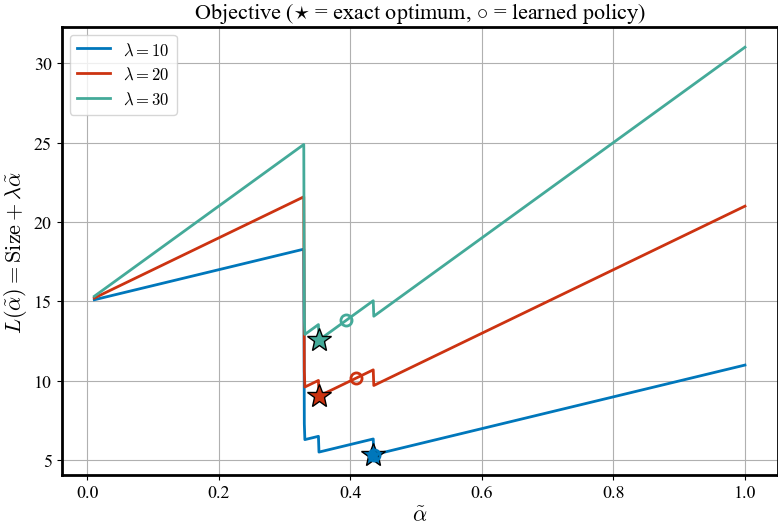

In [87]:
from tueplots import bundles
plt.rcParams.update(bundles.icml2024(usetex=False))
plt.rcParams.update({
    "axes.labelsize": 16, "axes.titlesize": 16,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "legend.fontsize": 12, "lines.linewidth": 2, "axes.linewidth": 2,
})
fig, ax = plt.subplots(figsize=(8, 5.5))
i_rep = int(np.argsort(S_test)[len(S_test) // 2])
s_rep = S_test_all[i_rep]
a_grid = np.linspace(1.0 / (n_calib + 1) + 1e-3, 1.0, 1200)
size_grid = np.array([exact_size(Sigma_full, s_rep, n_calib, a) for a in a_grid])

for lam in lambdas:
    L = size_grid + lam * a_grid
    ax.plot(a_grid, L, color=colors[lam], label=rf'$\lambda={lam}$')
    a_s, L_s = exact_min(Sigma_full, s_rep, n_calib, lam)
    ax.plot(a_s, L_s, marker='*', ms=18, color=colors[lam],
                mec='k', mew=1.0, ls='none', zorder=5)
    a_nn = float(learned_alphas(all_results[lam]['nets'][0], feats_test[i_rep:i_rep+1])[0])
    L_nn = exact_size(Sigma_full, s_rep, n_calib, a_nn) + lam * a_nn
    ax.plot(a_nn, L_nn, marker='o', ms=8, color='none', mec=colors[lam],
                mew=2, ls='none', zorder=6)

ax.set_xlabel(r"$\tilde\alpha$")
ax.set_ylabel(r"$L(\tilde\alpha)=\mathrm{Size}+\lambda\tilde\alpha$")
ax.set_title(r"Objective ($\star$ = exact optimum, $\circ$ = learned policy)")
ax.grid(True)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig("plots/exact_vs_learned_classification.pdf", format="pdf", bbox_inches="tight")
plt.savefig("plots/exact_vs_learned_classification.png", format="png", dpi=160, bbox_inches="tight")
plt.show()
